In [1]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# HHI and NCR 

# Based on some conversation with sir Gemidiot, I came up with a way to compute the maximum value for HHI index.
# 1st team wins all, 2nd team wins all but 1st, 3rd team wins all but 1st and 2nd, and so on...

def min_max_hhi(team_count):
    total_games = 2 * math.comb(team_count, 2)
    games_per_team = total_games * 2 / team_count
    team_points = np.repeat(np.array([games_per_team]), team_count)

    # uniformly distributed
    minimum_hhi = int(np.sum((team_points / (total_games * 2) * 100) ** 2))

    # Hierarchically distributed
    team_points = np.arange(0, games_per_team + 1, 2) * 3
    
    maximum_hhi = int(np.sum(((team_points) / (total_games * 3) * 100) ** 2))


    return minimum_hhi, maximum_hhi

def calculate_hhi(series):
    total_points = series.sum()
    hhi = int(np.sum((100 * series.values / total_points) ** 2))

    return hhi


In [3]:
leagues = ["Bundesliga", "La_Liga", "Ligue_1", "Premier_League", "Serie_A", "Super_Lig"]
nrc_indexes = {}

for league in leagues:
    df = pd.read_csv(f"data/omer/{league}_2015_to_2025.csv")
    nrc_indexes[league] = {}
    
    for season in df["Season"].unique():
        d = df.loc[df["Season"] == season, "Points"]
        
        hhi_index = calculate_hhi(d)
        min_hhi, max_hhi = min_max_hhi(len(d))
        nrc = round((hhi_index - min_hhi) / (max_hhi - min_hhi), 2)
        
        nrc_indexes[league][season] = nrc

nrc_indexes

{'Bundesliga': {'24/25': 0.27,
  '23/24': 0.41,
  '22/23': 0.22,
  '21/22': 0.25,
  '20/21': 0.27,
  '19/20': 0.29,
  '18/19': 0.33,
  '17/18': 0.23,
  '16/17': 0.22,
  '15/16': 0.28},
 'La_Liga': {'24/25': 0.3,
  '23/24': 0.4,
  '22/23': 0.23,
  '21/22': 0.22,
  '20/21': 0.3,
  '19/20': 0.25,
  '18/19': 0.18,
  '17/18': 0.3,
  '16/17': 0.4,
  '15/16': 0.3},
 'Ligue_1': {'24/25': 0.29,
  '23/24': 0.23,
  '22/23': 0.33,
  '21/22': 0.24,
  '20/21': 0.26,
  '19/20': 0.24,
  '18/19': 0.25,
  '17/18': 0.29,
  '16/17': 0.29,
  '15/16': 0.22},
 'Premier_League': {'24/25': 0.32,
  '23/24': 0.4,
  '22/23': 0.3,
  '21/22': 0.35,
  '20/21': 0.26,
  '19/20': 0.29,
  '18/19': 0.4,
  '17/18': 0.35,
  '16/17': 0.36,
  '15/16': 0.23},
 'Serie_A': {'24/25': 0.34,
  '23/24': 0.34,
  '22/23': 0.31,
  '21/22': 0.32,
  '20/21': 0.4,
  '19/20': 0.31,
  '18/19': 0.33,
  '17/18': 0.39,
  '16/17': 0.39,
  '15/16': 0.28},
 'Super_Lig': {'24/25': 0.41,
  '23/24': 0.38,
  '22/23': 0.34,
  '21/22': 0.21,
  '20/21'

In [8]:
nrc_indexes_df = pd.DataFrame(nrc_indexes)
nrc_indexes_df.reset_index(names="Season", inplace=True)
nrc_indexes_df.to_csv("NRC Table.csv", index=False)

nrc_indexes_df.head()

,Season,Bundesliga,La_Liga,Ligue_1,Premier_League,Serie_A,Super_Lig
0,24/25,0.27,0.30,0.29,0.32,0.34,0.41
1,23/24,0.41,0.40,0.23,0.40,0.34,0.38
2,22/23,0.22,0.23,0.33,0.30,0.31,0.34
3,21/22,0.25,0.22,0.24,0.35,0.32,0.21
4,20/21,0.27,0.30,0.26,0.26,0.40,0.22


In [5]:
# nrc_indexes_df.reset_index(names="Season", inplace=True)
nrc_indexes_melted = pd.melt(nrc_indexes_df, id_vars=["Season"], 
                             value_vars=["Bundesliga", "La_Liga",
                                         "Ligue_1",	"Premier_League", "Serie_A", "Super_Lig"],
                             var_name="League", value_name="NRC_value")

nrc_indexes_melted = nrc_indexes_melted.sort_values(by=["Season", "NRC_value"], ascending=[False, True])
display(nrc_indexes_melted.iloc[:18, ])

with pd.ExcelWriter('NRC_Tables.xlsx', mode='a', engine='openpyxl', if_sheet_exists='replace') as writer:
    # 2. Write the DataFrame to a NEW sheet using the writer object
    nrc_indexes_melted.iloc[:18, ].to_excel(writer, sheet_name='NRC Values', index=False)


,Season,League,NRC_value
0,24/25,Bundesliga,0.27
20,24/25,Ligue_1,0.29
10,24/25,La_Liga,0.30
30,24/25,Premier_League,0.32
40,24/25,Serie_A,0.34
50,24/25,Super_Lig,0.41
21,23/24,Ligue_1,0.23
41,23/24,Serie_A,0.34
51,23/24,Super_Lig,0.38
11,23/24,La_Liga,0.40


In [6]:
# AVG of the last three years
with pd.ExcelWriter('NRC_Tables.xlsx', mode='a', engine='openpyxl', if_sheet_exists='replace') as writer:
    nrc_indexes_melted.iloc[:18, ].groupby("League").agg({"NRC_value": "mean"}).reset_index().to_excel(writer, sheet_name="Average NRC's", index=False)

nrc_indexes_melted.iloc[:18, ].groupby("League").agg({"NRC_value": "mean"})

,NRC_value
League,
Bundesliga,0.300000
La_Liga,0.310000
Ligue_1,0.283333
Premier_League,0.340000
Serie_A,0.330000
Super_Lig,0.376667


C:\Users\alini\AppData\Local\Temp\ipykernel_4768\757397994.py:19: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  avg_ncr = nrc_indexes_df.mean().sort_values()


ValueError: could not convert string to float: '24/25'

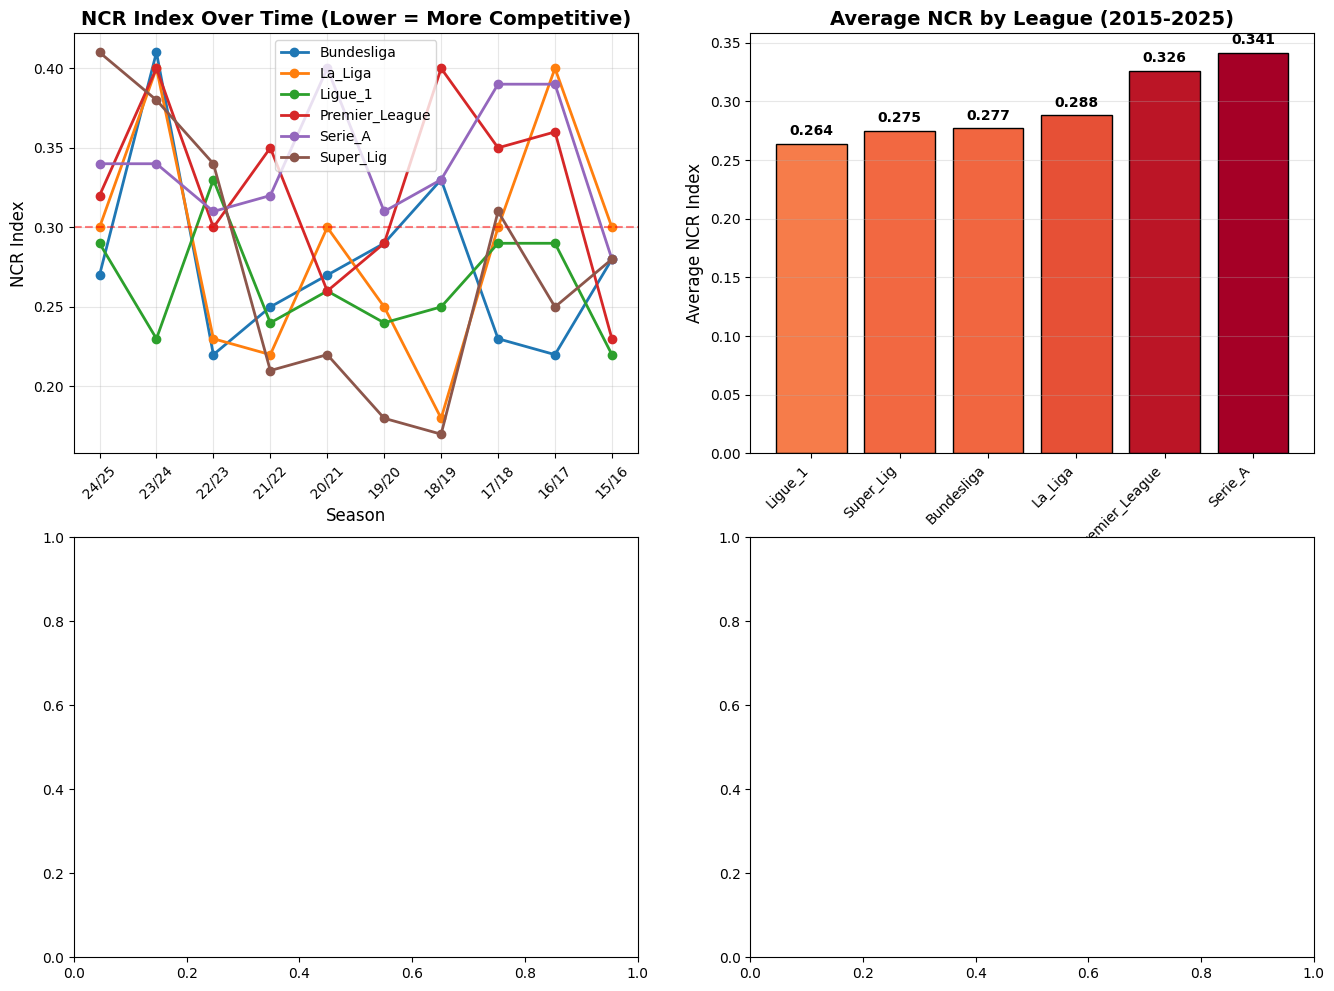

In [7]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))


ax1 = axes[0, 0]
for league in leagues:
    seasons = list(nrc_indexes[league].keys())
    values = list(nrc_indexes[league].values())
    ax1.plot(seasons, values, marker='o', label=league, linewidth=2, markersize=6)
ax1.set_title('NCR Index Over Time (Lower = More Competitive)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Season', fontsize=12)
ax1.set_ylabel('NCR Index', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)
ax1.axhline(y=0.3, color='red', linestyle='--', alpha=0.5, label='Moderate Competition')

ax2 = axes[0, 1]
avg_ncr = nrc_indexes_df.mean().sort_values()
colors = plt.cm.RdYlGn_r(avg_ncr / avg_ncr.max())
bars = ax2.bar(range(len(avg_ncr)), avg_ncr.values, color=colors, edgecolor='black')
ax2.set_xticks(range(len(avg_ncr)))
ax2.set_xticklabels(avg_ncr.index, rotation=45, ha='right')
ax2.set_title('Average NCR by League (2015-2025)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Average NCR Index', fontsize=12)
ax2.set_xlabel('League', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

for i, (bar, value) in enumerate(zip(bars, avg_ncr.values)):
    ax2.text(bar.get_x() + bar.get_width()/2., value + 0.005,
             f'{value:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax3 = axes[1, 0]
sns.heatmap(nrc_indexes_df.T, annot=True, fmt='.2f', cmap='RdYlGn_r',
            cbar_kws={'label': 'NCR Index'}, ax=ax3, vmin=0, vmax=0.5)
ax3.set_title('NCR Index Heatmap by League and Season', fontsize=14, fontweight='bold')
ax3.set_xlabel('Season', fontsize=12)
ax3.set_ylabel('League', fontsize=12)

ax4 = axes[1, 1]
box_data = [list(nrc_indexes[league].values()) for league in leagues]
bp = ax4.boxplot(box_data, labels=leagues, patch_artist=True)
for patch, color in zip(bp['boxes'], sns.color_palette("husl", len(leagues))):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax4.set_title('NCR Distribution by League', fontsize=14, fontweight='bold')
ax4.set_xlabel('League', fontsize=12)
ax4.set_ylabel('NCR Index', fontsize=12)
ax4.grid(True, alpha=0.3, axis='y')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('ncr_analysis.png', dpi=300, bbox_inches='tight')
plt.show()